<a href="https://colab.research.google.com/github/vermasparshika02/Patient-Readmission-Prediction/blob/main/Patient_Readmission_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Libraries**

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

# **Loading Dataset**

In [23]:
import os

print(os.listdir('/content'))

['.config', 'admissions.csv', 'sample_data']


In [24]:
df = pd.read_csv('/content/admissions.csv')

print(df.shape)
df.head()

(120000, 17)


,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,2024-01-23,2024-01-27,4,Elective,General,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Recovered,0,0,6.3,0.86,16.2,157,0,0
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,2019-11-18,2019-11-19,1,OPD,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,0,5.2,1.23,13.1,156,0,0
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,2019-11-22,2019-11-27,5,Emergency,General,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Recovered,0,2,5.6,0.67,10.9,130,1,0
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,2020-03-05,2020-03-16,11,Emergency,ICU,df4431ea-1acf-4e77-963c-6173e9787151,Recovered,1,2,4.7,1.40,8.8,159,1,0
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,2018-05-30,2018-06-04,5,Emergency,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,5,5.0,0.94,11.3,173,1,0


In [25]:
print(df.columns.tolist())

['admission_id', 'patient_id', 'admit_date', 'discharge_date', 'los_days', 'admit_type', 'ward_type', 'hospital_id', 'discharge_type', 'num_procedures', 'charlson_index', 'hba1c', 'creatinine', 'haemoglobin', 'systolic_bp', 'readmitted_30d', 'readmitted_7d']


# **Removing readmitted_7d(because it can leak information about future readmissions)**

In [26]:
X = df.drop(['readmitted_30d', 'readmitted_7d'], axis=1)

y = df['readmitted_30d']

In [27]:
print(X.columns)


Index(['admission_id', 'patient_id', 'admit_date', 'discharge_date',
       'los_days', 'admit_type', 'ward_type', 'hospital_id', 'discharge_type',
       'num_procedures', 'charlson_index', 'hba1c', 'creatinine',
       'haemoglobin', 'systolic_bp'],
      dtype='object')


In [28]:
df = df.drop('readmitted_7d', axis=1)

In [29]:
df.head()

,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,2024-01-23,2024-01-27,4,Elective,General,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Recovered,0,0,6.3,0.86,16.2,157,0
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,2019-11-18,2019-11-19,1,OPD,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,0,5.2,1.23,13.1,156,0
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,2019-11-22,2019-11-27,5,Emergency,General,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Recovered,0,2,5.6,0.67,10.9,130,1
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,2020-03-05,2020-03-16,11,Emergency,ICU,df4431ea-1acf-4e77-963c-6173e9787151,Recovered,1,2,4.7,1.40,8.8,159,1
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,2018-05-30,2018-06-04,5,Emergency,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,5,5.0,0.94,11.3,173,1


# **Basic Data Exploration**

In [30]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df['readmitted_30d'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   admission_id    120000 non-null  object 
 1   patient_id      120000 non-null  object 
 2   admit_date      120000 non-null  object 
 3   discharge_date  120000 non-null  object 
 4   los_days        120000 non-null  int64  
 5   admit_type      120000 non-null  object 
 6   ward_type       120000 non-null  object 
 7   hospital_id     120000 non-null  object 
 8   discharge_type  120000 non-null  object 
 9   num_procedures  120000 non-null  int64  
 10  charlson_index  120000 non-null  int64  
 11  hba1c           120000 non-null  float64
 12  creatinine      120000 non-null  float64
 13  haemoglobin     120000 non-null  float64
 14  systolic_bp     120000 non-null  int64  
 15  readmitted_30d  120000 non-null  int64  
dtypes: float64(3), int64(5), object(8)
memory usage: 14.6+ M

# **Class balance**

In [31]:
df['readmitted_30d'].value_counts(normalize=True)*100


,proportion
readmitted_30d,
0,88.158333
1,11.841667


# **Visualising Important Features**

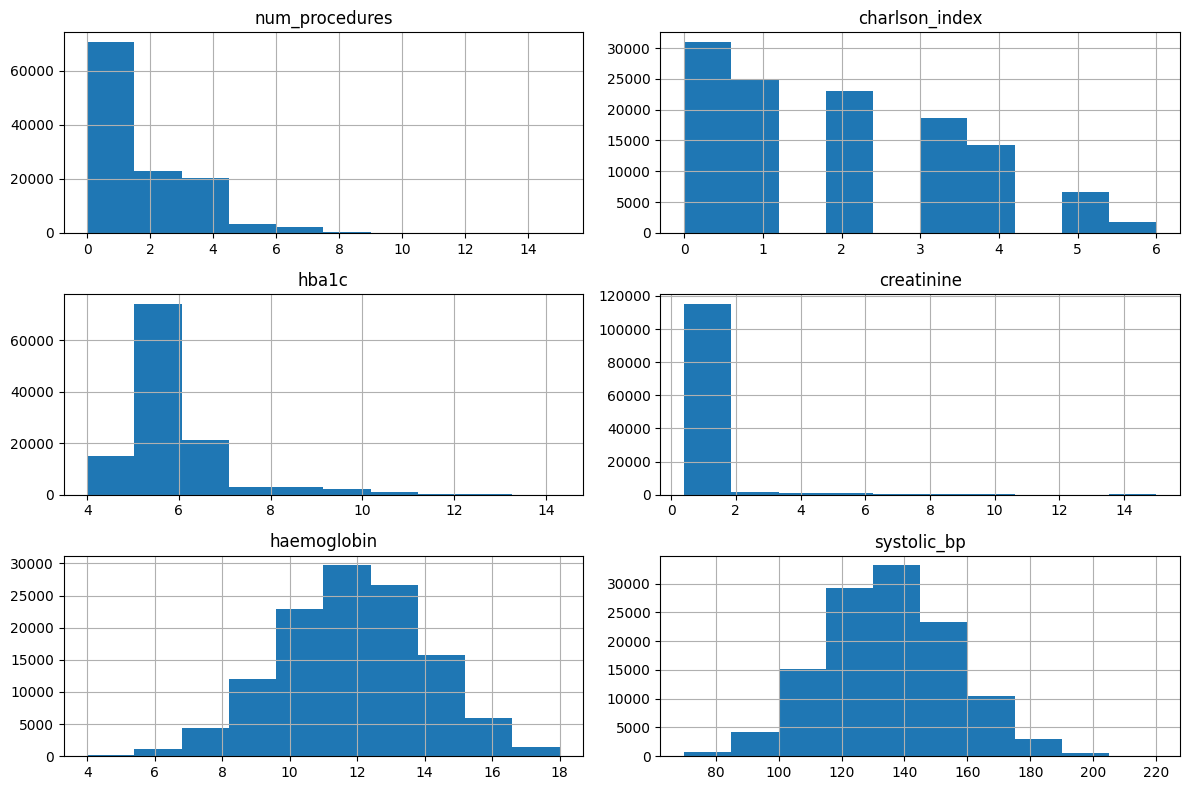

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = [
    'num_procedures',
    'charlson_index',
    'hba1c',
    'creatinine',
    'haemoglobin',
    'systolic_bp'
]

df[num_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

# **Correlation Heatmap**

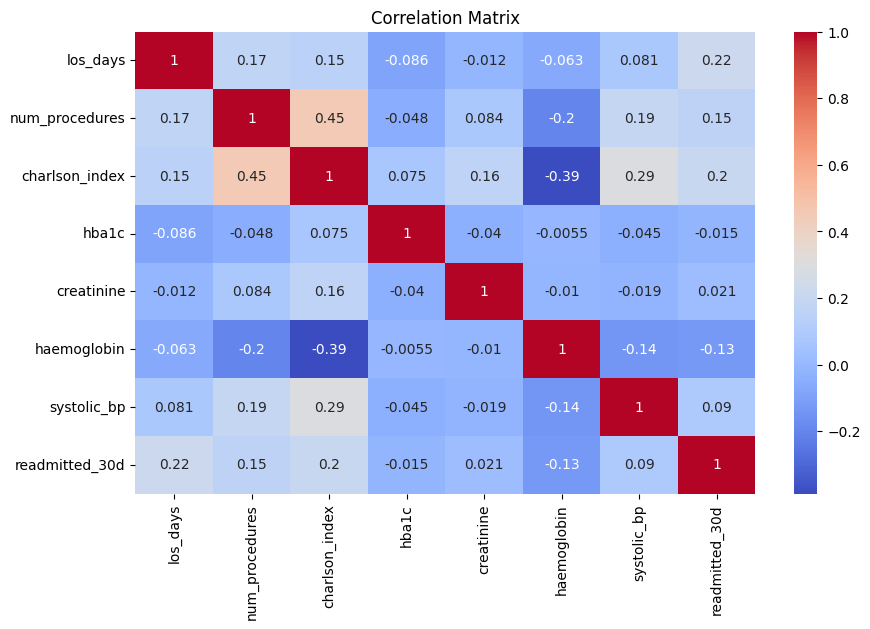

In [33]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

# **Encoding Categorical Variables**

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [35]:
# Features
X = df.drop('readmitted_30d', axis=1)

# Target
y = df['readmitted_30d']

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['admission_id', 'patient_id', 'admit_date', 'discharge_date', 'los_days', 'admit_type', 'ward_type', 'hospital_id', 'discharge_type', 'num_procedures', 'charlson_index', 'hba1c', 'creatinine', 'haemoglobin', 'systolic_bp']

Target:
readmitted_30d


# **Train-Test Split**

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (96000, 15)
Test set: (24000, 15)


In [37]:
print(X.dtypes)

admission_id        int64
patient_id          int64
admit_date          int64
discharge_date      int64
los_days            int64
admit_type          int64
ward_type           int64
hospital_id         int64
discharge_type      int64
num_procedures      int64
charlson_index      int64
hba1c             float64
creatinine        float64
haemoglobin       float64
systolic_bp         int64
dtype: object


# **Logistic Regression**

In [38]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [39]:
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

In [40]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    roc_auc_score
)

print("LOGISTIC REGRESSION")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("ROC-AUC  :", roc_auc_score(y_test, lr_prob))

LOGISTIC REGRESSION
Accuracy : 0.681375
Recall   : 0.6611541168191415
Precision: 0.21943244190120284
ROC-AUC  : 0.7368511329157875


# **Random Forest**

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [42]:
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

In [43]:
print("RANDOM FOREST")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

RANDOM FOREST
Accuracy : 0.8818333333333334
Recall   : 0.030260380014074596
Precision: 0.5180722891566265
ROC-AUC  : 0.7421004021949664


# **Comparing Models**

In [44]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

print(results)

                 Model    Recall   ROC_AUC
0  Logistic Regression  0.661154  0.736851
1        Random Forest  0.030260  0.742100


# **Feature Importance**

In [45]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

           Feature  Importance
13     haemoglobin    0.088372
1       patient_id    0.087695
0     admission_id    0.087237
4         los_days    0.084256
12      creatinine    0.079219
14     systolic_bp    0.078140
2       admit_date    0.078122
3   discharge_date    0.077969
10  charlson_index    0.069895
7      hospital_id    0.067104
11           hba1c    0.066446
8   discharge_type    0.045702
9   num_procedures    0.037739
6        ward_type    0.036035
5       admit_type    0.016069


# **Visualization**

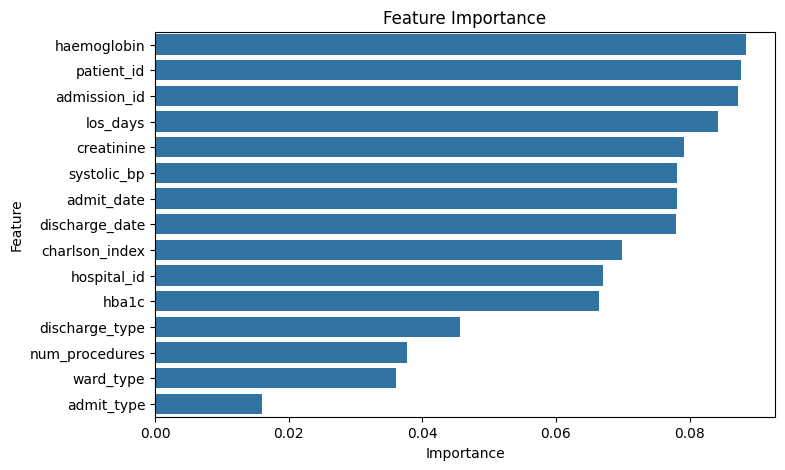

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

# **Confusion Matrix**

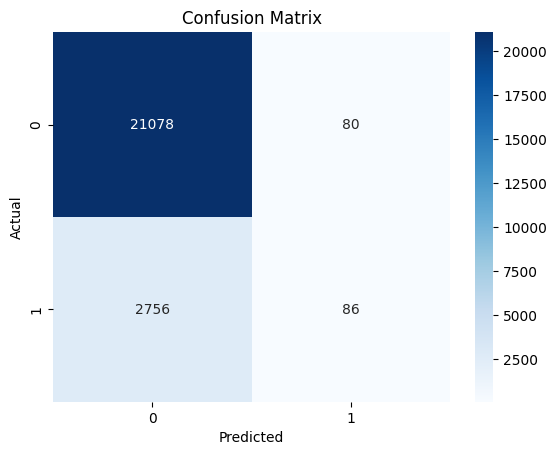

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **ROC Curve**

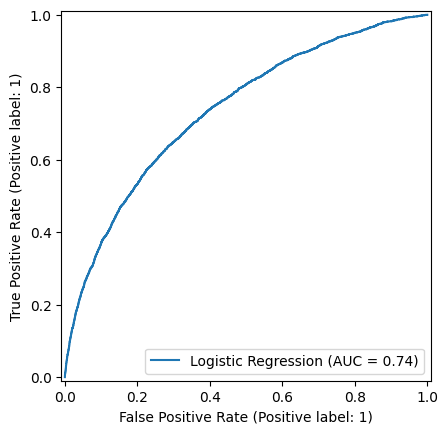

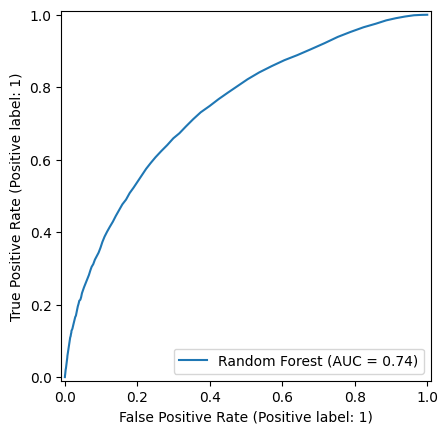

In [48]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    lr,
    X_test,
    y_test,
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    name="Random Forest"
)

plt.show()

In [51]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score

print("LOGISTIC REGRESSION")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Recall :", recall_score(y_test, lr_pred))
print("Precision :", precision_score(y_test, lr_pred))
print("ROC-AUC :", roc_auc_score(y_test, lr_prob))

LOGISTIC REGRESSION
Accuracy : 0.681375
Recall : 0.6611541168191415
Precision : 0.21943244190120284
ROC-AUC : 0.7368511329157875


In [52]:
print("RANDOM FOREST")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Recall :", recall_score(y_test, rf_pred))
print("Precision :", precision_score(y_test, rf_pred))
print("ROC-AUC :", roc_auc_score(y_test, rf_prob))

RANDOM FOREST
Accuracy : 0.8818333333333334
Recall : 0.030260380014074596
Precision : 0.5180722891566265
ROC-AUC : 0.7421004021949664


In [55]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

           Feature  Importance
13     haemoglobin    0.088372
1       patient_id    0.087695
0     admission_id    0.087237
4         los_days    0.084256
12      creatinine    0.079219
14     systolic_bp    0.078140
2       admit_date    0.078122
3   discharge_date    0.077969
10  charlson_index    0.069895
7      hospital_id    0.067104
11           hba1c    0.066446
8   discharge_type    0.045702
9   num_procedures    0.037739
6        ward_type    0.036035
5       admit_type    0.016069


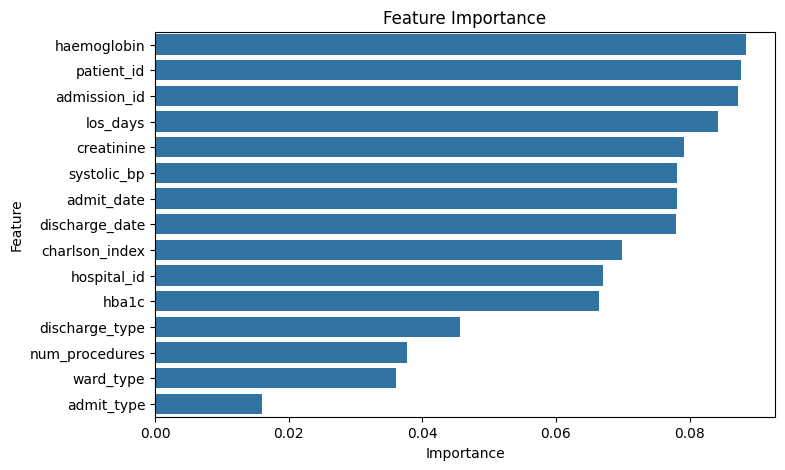

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()